## Ejemplo Práctico de K-NN

Ejemplo Práctico de Escalamiento

In [48]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import numpy as np

# Datos originales
X = np.array([[180, 75], [165, 65], [170, 70], [160, 60]])


# Min-Max Scaling
min_max_scaler = MinMaxScaler()
X_minmax = min_max_scaler.fit_transform(X)

# Estandarización
std_scaler = StandardScaler()
X_std = std_scaler.fit_transform(X)


print("Datos originales:\n", X)
print("\nDatos normalizados (Min-Max):\n", X_minmax)
print("\nDatos estandarizados (Z-Score):\n", X_std)

Datos originales:
 [[180  75]
 [165  65]
 [170  70]
 [160  60]]

Datos normalizados (Min-Max):
 [[1.         1.        ]
 [0.25       0.33333333]
 [0.5        0.66666667]
 [0.         0.        ]]

Datos estandarizados (Z-Score):
 [[ 1.52127766  1.34164079]
 [-0.50709255 -0.4472136 ]
 [ 0.16903085  0.4472136 ]
 [-1.18321596 -1.34164079]]


In [49]:
import numpy as np
# Definimos los puntos
A = np.array([180, 75])
B = np.array([170, 70])
# Calculamos la distancia euclideana
distancia = np.sqrt(np.sum((A - B)**2))
print(f"La distancia euclideana entre A y B es: {distancia}")

La distancia euclideana entre A y B es: 11.180339887498949


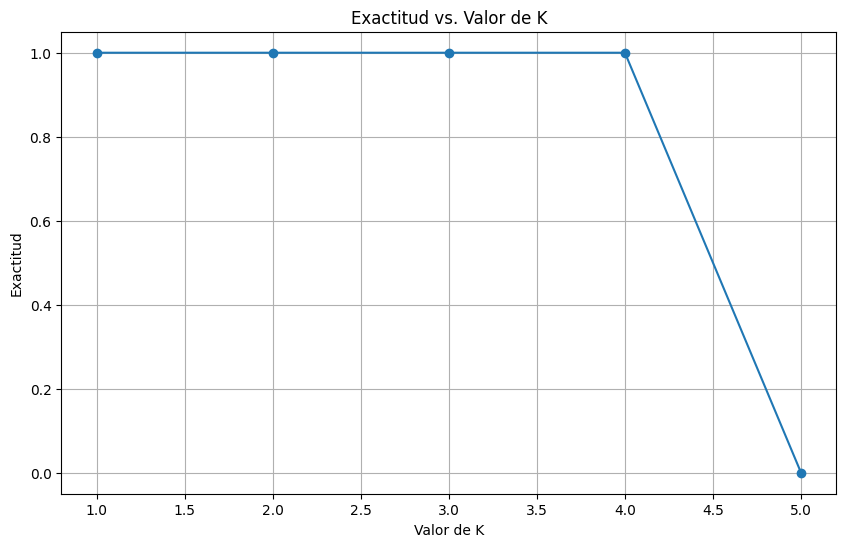

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Datos de ejemplo
X = np.array([[180, 75], [165, 65], [170, 70], [160, 60],  [175, 72], [162, 63], [178, 74], [168, 68]])
y = np.array(['Fútbol', 'Baloncesto', 'Fútbol', 'Baloncesto', 'Fútbol', 'Baloncesto', 'Fútbol', 'Baloncesto'])

# Dividir datos y escalar
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Probar diferentes valores de K
k_values = range(1, 6)
accuracies = []

for k in k_values:
  knn = KNeighborsClassifier(n_neighbors=k)
  knn.fit(X_train_scaled, y_train)
  y_pred = knn.predict(X_test_scaled)
  accuracies.append(accuracy_score(y_test, y_pred))

# Graficar resultados
plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies, marker='o')
plt.title('Exactitud vs. Valor de K')
plt.xlabel('Valor de K')
plt.ylabel('Exactitud')
plt.grid(True)
plt.show()

## Live Coding

**0) Setup**

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, classification_report


**1) Dataset simple y limpio**

In [52]:
import pandas as pd

df = pd.DataFrame({
    "Altura_cm": [180,165,170,160,175,168,182,158,172,166,178,162,171,159,176,167],
    "Peso_kg":   [75, 65, 70, 60, 72, 66, 78, 59, 71, 64, 74, 61, 69, 58, 73, 67],
    "Deporte":   ["Futbol","Baloncesto","Futbol","Baloncesto",
                  "Futbol","Baloncesto","Futbol","Baloncesto",
                  "Futbol","Baloncesto","Futbol","Baloncesto",
                  "Futbol","Baloncesto","Futbol","Baloncesto"]
})
df.head()

,Altura_cm,Peso_kg,Deporte
0,180,75,Futbol
1,165,65,Baloncesto
2,170,70,Futbol
3,160,60,Baloncesto
4,175,72,Futbol


In [53]:
# Separar X e y
X = df[["Altura_cm", "Peso_kg"]]
y = df["Deporte"]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

**2) Aplicación de StandardScaler y MinMaxScaler.**

In [54]:
std_scaler = StandardScaler()
mm_scaler  = MinMaxScaler()

X_train_std = std_scaler.fit_transform(X_train)
X_test_std  = std_scaler.transform(X_test)

X_train_mm = mm_scaler.fit_transform(X_train)
X_test_mm  = mm_scaler.transform(X_test)

**3) Implementación de KNeighborsClassifier.**

In [55]:
k_inicial = 3

knn_std = KNeighborsClassifier(n_neighbors=k_inicial)
knn_std.fit(X_train_std, y_train)

knn_mm = KNeighborsClassifier(n_neighbors=k_inicial)
knn_mm.fit(X_train_mm, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


**4) Evaluación de precisión para diferentes valores de K.**

In [56]:
len(X_train)

12

In [57]:
k_values = range(1, len(X_train) + 1)
acc_std = []
acc_mm = []

for k in k_values:
    m1 = KNeighborsClassifier(n_neighbors=k).fit(X_train_std, y_train)
    m2 = KNeighborsClassifier(n_neighbors=k).fit(X_train_mm, y_train)

    acc_std.append(m1.score(X_test_std, y_test))
    acc_mm.append(m2.score(X_test_mm, y_test))

best_k_std = k_values[int(np.argmax(acc_std))]
best_k_mm  = k_values[int(np.argmax(acc_mm))]

print("Mejor K (StandardScaler):", best_k_std, " | Accuracy:", max(acc_std))
print("Mejor K (MinMaxScaler): ", best_k_mm,  " | Accuracy:", max(acc_mm), "\n")

Mejor K (StandardScaler): 1  | Accuracy: 1.0
Mejor K (MinMaxScaler):  1  | Accuracy: 1.0 



**5) Visualización de exactitud con Matplotlib.**

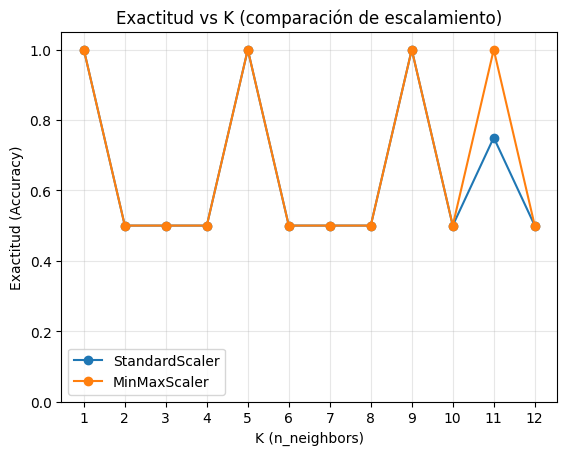

In [58]:
plt.plot(list(k_values), acc_std, marker="o", label="StandardScaler")
plt.plot(list(k_values), acc_mm, marker="o", label="MinMaxScaler")
plt.xlabel("K (n_neighbors)")
plt.ylabel("Exactitud (Accuracy)")
plt.title("Exactitud vs K (comparación de escalamiento)")
plt.xticks(list(k_values))
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**6) Uso de matriz de confusión y F1-score.**

In [59]:
final_std = KNeighborsClassifier(n_neighbors=best_k_std).fit(X_train_std, y_train)
final_mm  = KNeighborsClassifier(n_neighbors=best_k_mm).fit(X_train_mm, y_train)

pred_std = final_std.predict(X_test_std)
pred_mm  = final_mm.predict(X_test_mm)

acc_final_std = accuracy_score(y_test, pred_std)
acc_final_mm  = accuracy_score(y_test, pred_mm)

f1_final_std = f1_score(y_test, pred_std, average="weighted")
f1_final_mm  = f1_score(y_test, pred_mm,  average="weighted")

print("=== StandardScaler (mejor K) ===")
print("Accuracy:", acc_final_std)
print("F1-score (weighted):", f1_final_std)
print("Matriz de confusión:\n", confusion_matrix(y_test, pred_std))
print("\nReporte:\n", classification_report(y_test, pred_std), "\n")

print("=== MinMaxScaler (mejor K) ===")
print("Accuracy:", acc_final_mm)
print("F1-score (weighted):", f1_final_mm)
print("Matriz de confusión:\n", confusion_matrix(y_test, pred_mm))
print("\nReporte:\n", classification_report(y_test, pred_mm), "\n")

=== StandardScaler (mejor K) ===
Accuracy: 1.0
F1-score (weighted): 1.0
Matriz de confusión:
 [[2 0]
 [0 2]]

Reporte:
               precision    recall  f1-score   support

  Baloncesto       1.00      1.00      1.00         2
      Futbol       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4
 

=== MinMaxScaler (mejor K) ===
Accuracy: 1.0
F1-score (weighted): 1.0
Matriz de confusión:
 [[2 0]
 [0 2]]

Reporte:
               precision    recall  f1-score   support

  Baloncesto       1.00      1.00      1.00         2
      Futbol       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4
 



**7) Elección del modelo final.**


In [60]:
# (criterio simple: mayor F1; si empata, mayor accuracy)
use_std = (f1_final_std > f1_final_mm) or (f1_final_std == f1_final_mm and acc_final_std >= acc_final_mm)

if use_std:
    modelo_final = final_std
    scaler_final = std_scaler
    nombre_final = f"KNN + StandardScaler (K={best_k_std})"
else:
    modelo_final = final_mm
    scaler_final = mm_scaler
    nombre_final = f"KNN + MinMaxScaler (K={best_k_mm})"

print("✅ Modelo final elegido:", nombre_final, "\n")

✅ Modelo final elegido: KNN + StandardScaler (K=1) 



**8) Predicción con datos nuevos.**

In [61]:
nuevo = pd.DataFrame({"Altura_cm":[172], "Peso_kg":[72]})
nuevo_scaled = scaler_final.transform(nuevo)

pred_nuevo = modelo_final.predict(nuevo_scaled)[0]
proba = None
if hasattr(modelo_final, "predict_proba"):
    proba = modelo_final.predict_proba(nuevo_scaled)[0]

print("Nuevo dato:", nuevo.iloc[0].to_dict())
print("Predicción:", pred_nuevo)

if proba is not None:
    clases = modelo_final.classes_
    print("Probabilidades:", {clases[i]: float(proba[i]) for i in range(len(clases))})

Nuevo dato: {'Altura_cm': 172, 'Peso_kg': 72}
Predicción: Futbol
Probabilidades: {'Baloncesto': 0.0, 'Futbol': 1.0}


## Ejercicio 1

In [62]:
import numpy as np
import pandas as pd

np.random.seed(42)

n = 1000

edad = np.random.randint(21, 70, n)
ingresos = np.random.normal(800000, 300000, n).clip(300000, 2000000)
score_crediticio = np.random.normal(600, 100, n).clip(300, 850)
antiguedad_cliente = np.random.randint(0, 20, n)
deudas_actuales = np.random.normal(2000000, 1500000, n).clip(0, 8000000)

estado_civil = np.random.choice(['Soltero', 'Casado', 'Divorciado'], n)
educacion = np.random.choice(['Media', 'Tecnica', 'Universitaria', 'Postgrado'], n)

# Regla lógica para aprobación (no totalmente aleatoria)
prob_aprobacion = (
    (score_crediticio > 650).astype(int) +
    (ingresos > 900000).astype(int) +
    (deudas_actuales < 2500000).astype(int)
)

aprobacion_prestamo = (prob_aprobacion >= 2).astype(int)

df = pd.DataFrame({
    "edad": edad,
    "ingresos": ingresos.astype(int),
    "score_crediticio": score_crediticio.astype(int),
    "antiguedad_cliente": antiguedad_cliente,
    "deudas_actuales": deudas_actuales.astype(int),
    "estado_civil": estado_civil,
    "educacion": educacion,
    "aprobacion_prestamo": aprobacion_prestamo
})

df.to_csv("clientes_banco.csv", index=False)

print("Dataset generado correctamente")
print(df.head())

Dataset generado correctamente
   edad  ingresos  score_crediticio  antiguedad_cliente  deudas_actuales  \
0    59    852189               509                   0           571525   
1    49   1072361               569                  16           984507   
2    35    797362               512                  10           841010   
3    63    935423               678                   9          3245287   
4    28   1044755               541                  18          3350597   

  estado_civil      educacion  aprobacion_prestamo  
0      Soltero      Postgrado                    0  
1      Soltero        Tecnica                    1  
2      Soltero        Tecnica                    0  
3   Divorciado  Universitaria                    1  
4       Casado        Tecnica                    0  


**1) Cargar dataset**

In [63]:
import pandas as pd

df = pd.read_csv("clientes_banco.csv")

print("Dimensiones:", df.shape)
df.head()

Dimensiones: (1000, 8)


,edad,ingresos,score_crediticio,antiguedad_cliente,deudas_actuales,estado_civil,educacion,aprobacion_prestamo
0,59,852189,509,0,571525,Soltero,Postgrado,0
1,49,1072361,569,16,984507,Soltero,Tecnica,1
2,35,797362,512,10,841010,Soltero,Tecnica,0
3,63,935423,678,9,3245287,Divorciado,Universitaria,1
4,28,1044755,541,18,3350597,Casado,Tecnica,0


**2) Exploración inicial**

In [64]:
print(df.info())
print(df.describe())

print("\nValores faltantes:")
print(df.isnull().sum())

print("\nDistribución del target:")
print(df["aprobacion_prestamo"].value_counts(normalize=True))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   edad                 1000 non-null   int64 
 1   ingresos             1000 non-null   int64 
 2   score_crediticio     1000 non-null   int64 
 3   antiguedad_cliente   1000 non-null   int64 
 4   deudas_actuales      1000 non-null   int64 
 5   estado_civil         1000 non-null   object
 6   educacion            1000 non-null   object
 7   aprobacion_prestamo  1000 non-null   int64 
dtypes: int64(6), object(2)
memory usage: 62.6+ KB
None
              edad      ingresos  score_crediticio  antiguedad_cliente  \
count  1000.000000  1.000000e+03       1000.000000         1000.000000   
mean     45.379000  8.308452e+05        601.219000            9.980000   
std      14.122138  3.033825e+05         98.207463            5.633945   
min      21.000000  3.000000e+05        300.000000   

**3 y 4) Escalamiento + One Hot Encoding**

In [65]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Separar variables
X = df.drop("aprobacion_prestamo", axis=1)
y = df["aprobacion_prestamo"]

# Identificar columnas
num_cols = X.select_dtypes(include=["int64","float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

print("Numéricas:", num_cols)
print("Categóricas:", cat_cols)

Numéricas: Index(['edad', 'ingresos', 'score_crediticio', 'antiguedad_cliente',
       'deudas_actuales'],
      dtype='object')
Categóricas: Index(['estado_civil', 'educacion'], dtype='object')


In [66]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [67]:
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

**5 y 6) Entrenar KNN con varios K**

In [68]:
from sklearn.neighbors import KNeighborsClassifier

k_values = range(1,21)

results = []

for k in k_values:

    model = Pipeline(steps=[
        ("preprocess", preprocess),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    from sklearn.metrics import accuracy_score, f1_score

    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred)

    results.append((k, acc, f1))

In [69]:
results_df = pd.DataFrame(results, columns=["K","Accuracy","F1"])
results_df.head()

,K,Accuracy,F1
0,1,0.830000,0.801556
1,2,0.800000,0.711538
2,3,0.850000,0.814815
3,4,0.830000,0.771300
4,5,0.866667,0.836066


**7) Accuracy, matriz de confusión y F1 por K**

In [70]:
best_k = results_df.loc[results_df["F1"].idxmax(),"K"]
print("Mejor K:", best_k)

Mejor K: 13


In [71]:
final_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("knn", KNeighborsClassifier(n_neighbors=int(best_k)))
])

final_model.fit(X_train, y_train)

y_pred_final = final_model.predict(X_test)

In [72]:
from sklearn.metrics import confusion_matrix, classification_report

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_final))
print("\nClassification Report:\n", classification_report(y_test, y_pred_final))

Confusion Matrix:
 [[165   8]
 [ 22 105]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.95      0.92       173
           1       0.93      0.83      0.88       127

    accuracy                           0.90       300
   macro avg       0.91      0.89      0.90       300
weighted avg       0.90      0.90      0.90       300



**8) Gráfica impacto de K**

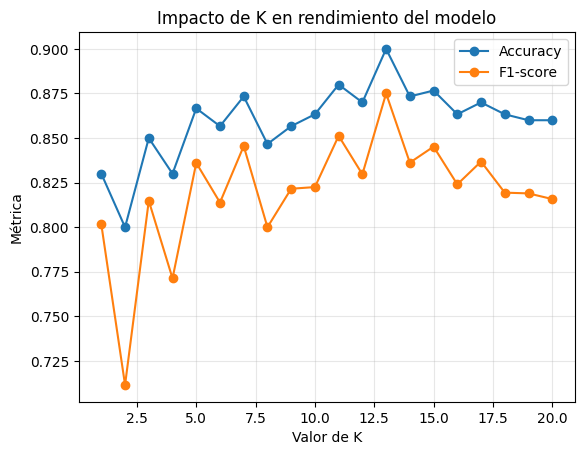

In [73]:
import matplotlib.pyplot as plt

plt.plot(results_df["K"], results_df["Accuracy"], marker="o", label="Accuracy")
plt.plot(results_df["K"], results_df["F1"], marker="o", label="F1-score")

plt.xlabel("Valor de K")
plt.ylabel("Métrica")
plt.title("Impacto de K en rendimiento del modelo")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**9) Elegir mejor K y explicar**

**10) Predicción cliente nuevo**

In [74]:
nuevo_cliente = pd.DataFrame({
    "edad":[35],
    "ingresos":[1200000],
    "score_crediticio":[600],
    "antiguedad_cliente":[5],
    "deudas_actuales":[1000000],
    "estado_civil":["Casado"],
    "educacion":["Universitaria"]
})

pred = final_model.predict(nuevo_cliente)
proba = final_model.predict_proba(nuevo_cliente)

print("Predicción:", pred[0])
print("Probabilidad:", proba)

Predicción: 1
Probabilidad: [[0.23076923 0.76923077]]


# PARTE 2

## Ejemplo Completo de Implementación

In [75]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
# Datos de ejemplo (altura, peso, deporte)
X = np.array([[180, 75], [165, 65], [170, 70], [160, 60],  [175, 72], [162, 63], [178, 74], [168, 68], [182, 78], [163, 64], [172, 71], [158, 59]])
y = np.array(['Fútbol', 'Baloncesto', 'Fútbol', 'Baloncesto', 'Fútbol', 'Baloncesto', 'Fútbol', 'Baloncesto', 'Fútbol', 'Baloncesto', 'Fútbol', 'Baloncesto'])
# Dividir datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
# Escalar los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# Crear y entrenar el modelo K-NN
k = 3 # Número de vecinos
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train_scaled, y_train)
# Realizar predicciones
y_pred = knn.predict(X_test_scaled)
# Evaluar el modelo
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)
print(f"Exactitud: {accuracy:.2f}")
print("\nMatriz de Confusión:")
print(conf_matrix)
print("\nInforme de Clasificación:")
print(class_report)

Exactitud: 1.00

Matriz de Confusión:
[[1 0]
 [0 3]]

Informe de Clasificación:
              precision    recall  f1-score   support

  Baloncesto       1.00      1.00      1.00         1
      Fútbol       1.00      1.00      1.00         3

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



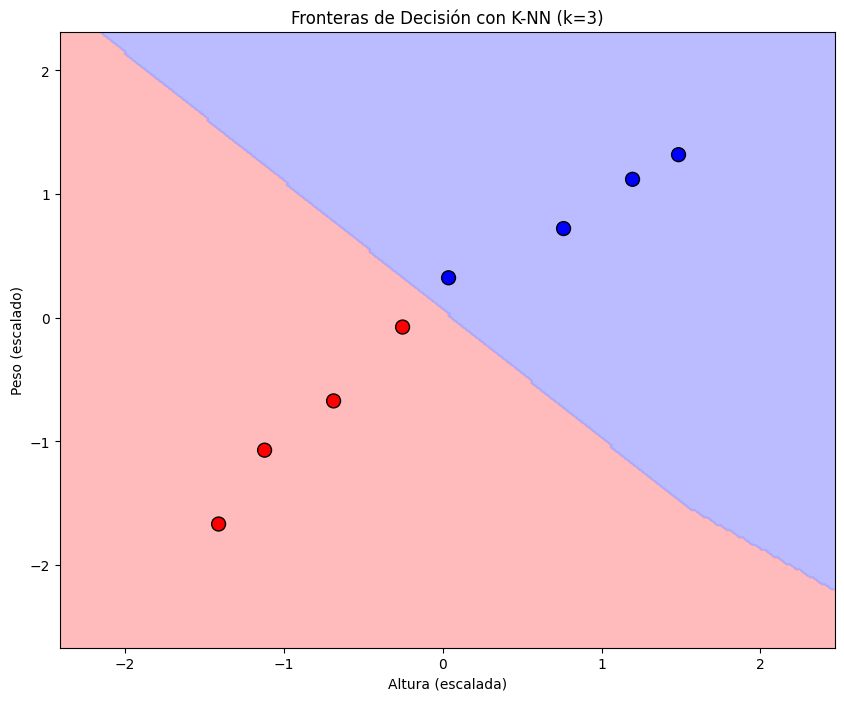

In [76]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from matplotlib.colors import ListedColormap
# Datos de ejemplo
X = np.array([[180, 75], [165, 65], [170, 70], [160, 60],  [175, 72], [162, 63], [178, 74], [168, 68]])
y = np.array(['Fútbol', 'Baloncesto', 'Fútbol', 'Baloncesto', 'Fútbol', 'Baloncesto', 'Fútbol', 'Baloncesto'])
# Escalar los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# Crear y entrenar el modelo K-NN
k = 3
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_scaled, y)
# Crear malla para visualizar fronteras de decisión
h = 0.02 # Tamaño del paso en la malla
x_min, x_max = X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1
y_min, y_max = X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
# Predecir clase para cada punto en la malla
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = np.array([1 if z == 'Fútbol' else 0 for z in Z])
Z = Z.reshape(xx.shape)
# Visualizar resultado
plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.8, cmap=ListedColormap(['#FFAAAA', '#AAAAFF']))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=[1 if y_i == 'Fútbol' else 0 for y_i in y],  cmap=ListedColormap(['#FF0000', '#0000FF']), edgecolor='k', s=100)
plt.title(f'Fronteras de Decisión con K-NN (k={k})')
plt.xlabel('Altura (escalada)')
plt.ylabel('Peso (escalado)')
plt.show()

## Ejemplo PCA

El PCA (Análisis de Componentes Principales) es una técnica que permite reducir la cantidad de variables de un dataset sin perder demasiada información. Lo hace transformando las variables originales en nuevas variables llamadas componentes principales, que son combinaciones lineales de las anteriores y están ordenadas según la cantidad de varianza que explican.

En términos simples, PCA busca las direcciones donde los datos varían más y las usa como nuevos ejes. Así, es posible representar la misma información con menos dimensiones, lo que ayuda a visualizar datos complejos y a mejorar el desempeño de algunos modelos cuando hay muchas variables correlacionadas

In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# =========================
# 1) Dataset concreto (5 puntos)
# =========================
df = pd.DataFrame({
    "Altura_cm": [170, 172, 168, 174, 169],
    "Peso_kg":   [65,  67,  63,  70,  64]
})

X = df[["Altura_cm", "Peso_kg"]].values
print("=== Datos originales ===")
print(df, "\n")

=== Datos originales ===
   Altura_cm  Peso_kg
0        170       65
1        172       67
2        168       63
3        174       70
4        169       64 



* PCA trabaja con la matriz de covarianza, así que primero se centran los datos (restar la media).

In [78]:
# =========================
# 2) Centrar (restar la media)
# =========================
mean = X.mean(axis=0)
X_centered = X - mean

print("=== Media de cada variable ===")
print(f"Media Altura: {mean[0]:.2f} cm")
print(f"Media Peso:   {mean[1]:.2f} kg\n")

print("=== Datos centrados (X - media) ===")
df_centered = pd.DataFrame(X_centered, columns=["Altura_centrada", "Peso_centrado"])
print(df_centered, "\n")

=== Media de cada variable ===
Media Altura: 170.60 cm
Media Peso:   65.80 kg

=== Datos centrados (X - media) ===
   Altura_centrada  Peso_centrado
0             -0.6           -0.8
1              1.4            1.2
2             -2.6           -2.8
3              3.4            4.2
4             -1.6           -1.8 



* Matriz de covarianza

In [79]:
# =========================
# 3) Matriz de covarianza (sobre datos centrados)
# rowvar=False: columnas son variables
# =========================
cov = np.cov(X_centered, rowvar=False)

print("=== Matriz de covarianza ===")
print(cov, "\n")

=== Matriz de covarianza ===
[[5.8  6.65]
 [6.65 7.7 ]] 



* Eigenvectores y Eigenvalores

    PCA busca:

    * Eigenvectores → nuevas direcciones (los ejes rotados)
    * Eigenvalores → cuánta varianza hay en cada dirección

In [80]:
# =========================
# 4) Autovalores y autovectores (PCA "matemático")
# Para matrices simétricas, usar eigh (más estable)
# =========================
eigvals, eigvecs = np.linalg.eigh(cov)

# Ordenar de mayor a menor (porque eigh viene de menor a mayor)
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

print("=== Autovalores (varianza en cada componente) ===")
print(eigvals, "\n")

print("=== Autovectores (direcciones de PC1 y PC2) ===")
# Cada columna es un autovector
print(eigvecs, "\n")

explained_ratio = eigvals / eigvals.sum()
print("=== Varianza explicada (ratio) ===")
print(f"PC1: {explained_ratio[0]:.4f} ({explained_ratio[0]*100:.2f}%)")
print(f"PC2: {explained_ratio[1]:.4f} ({explained_ratio[1]*100:.2f}%)\n")

=== Autovalores (varianza en cada componente) ===
[13.46751442  0.03248558] 

=== Autovectores (direcciones de PC1 y PC2) ===
[[ 0.65520174 -0.75545395]
 [ 0.75545395  0.65520174]] 

=== Varianza explicada (ratio) ===
PC1: 0.9976 (99.76%)
PC2: 0.0024 (0.24%)



* Proyección

PC1=a * altura + b * peso

In [81]:
# =========================
# 5) Proyección a componentes principales (manual)
# PC scores = X_centered dot eigenvectors
# =========================
X_pca_manual = X_centered @ eigvecs

print("=== Proyección (scores) en PC1 y PC2 (manual) ===")
df_pca_manual = pd.DataFrame(X_pca_manual, columns=["PC1", "PC2"])
print(df_pca_manual, "\n")

=== Proyección (scores) en PC1 y PC2 (manual) ===
        PC1       PC2
0 -0.997484 -0.070889
1  1.823827 -0.271393
2 -3.818796  0.129615
3  5.400593  0.183304
4 -2.408140  0.029363 



In [82]:
# =========================
# 6) PCA con sklearn (para comparar)
# =========================
pca = PCA(n_components=2)
X_pca_sklearn = pca.fit_transform(X)

print("=== sklearn PCA: varianza explicada ===")
print(pca.explained_variance_ratio_, "\n")

print("=== sklearn PCA: componentes ===")
print(pca.components_, "\n")

# Nota: Los autovectores pueden venir con signo invertido (equivalente).
# PC1 y PC2 pueden diferir por un "-" y sigue siendo el mismo eje.

=== sklearn PCA: varianza explicada ===
[0.99759366 0.00240634] 

=== sklearn PCA: componentes ===
[[ 0.65520174  0.75545395]
 [ 0.75545395 -0.65520174]] 



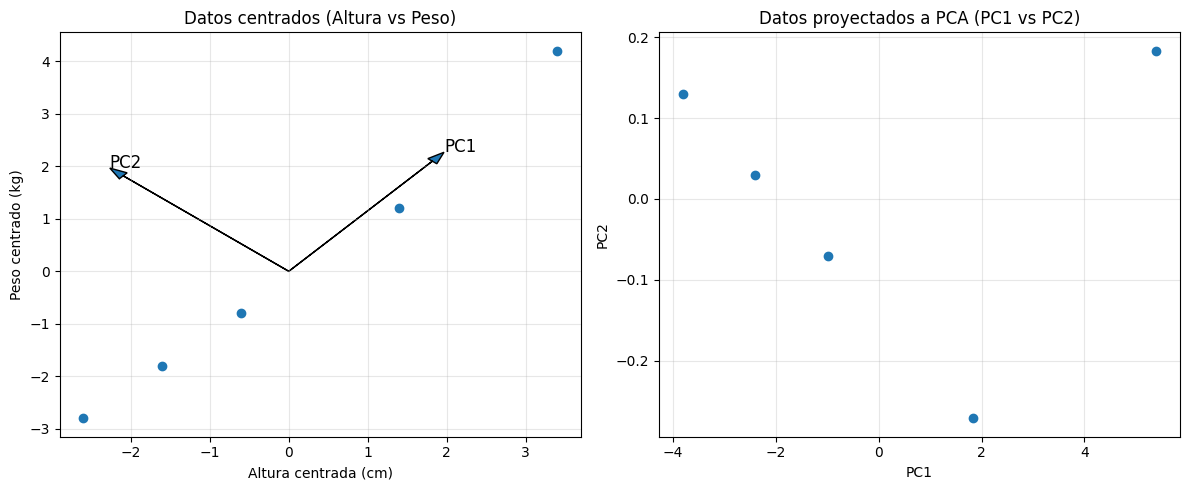

In [83]:
# =========================
# 7) Visualización: original vs PCA
# =========================
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# --- A) Datos centrados + ejes PC
ax[0].scatter(X_centered[:, 0], X_centered[:, 1])
ax[0].set_title("Datos centrados (Altura vs Peso)")
ax[0].set_xlabel("Altura centrada (cm)")
ax[0].set_ylabel("Peso centrado (kg)")
ax[0].grid(alpha=0.3)

origin = np.array([0.0, 0.0])
scale = 3.0  # solo para que se vean las flechas

pc1 = eigvecs[:, 0] * scale
pc2 = eigvecs[:, 1] * scale

ax[0].arrow(origin[0], origin[1], pc1[0], pc1[1], head_width=0.15, length_includes_head=True)
ax[0].arrow(origin[0], origin[1], pc2[0], pc2[1], head_width=0.15, length_includes_head=True)
ax[0].text(pc1[0], pc1[1], "PC1", fontsize=12)
ax[0].text(pc2[0], pc2[1], "PC2", fontsize=12)

# --- B) Datos en espacio PCA (manual)
ax[1].scatter(X_pca_manual[:, 0], X_pca_manual[:, 1])
ax[1].set_title("Datos proyectados a PCA (PC1 vs PC2)")
ax[1].set_xlabel("PC1")
ax[1].set_ylabel("PC2")
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [84]:
# =========================
# 8) Reducción a 1 dimensión (solo PC1)
# =========================
X_1d = X_pca_manual[:, 0]  # solo PC1

print("=== Reducción a 1D (solo PC1) ===")
print(X_1d)

=== Reducción a 1D (solo PC1) ===
[-0.99748421  1.82382718 -3.8187956   5.40059253 -2.40813991]


## Live Coding

**1) Cargar dataset**

In [85]:
import pandas as pd

df = pd.read_csv("deportes.csv")

print("Dimensiones:", df.shape)
print(df.head())
print(df["deporte"].value_counts())

Dimensiones: (60, 3)
   altura  peso deporte
0   172.5  65.6  Futbol
1   169.3  75.4  Futbol
2   173.2  67.9  Futbol
3   177.6  63.8  Futbol
4   168.8  71.3  Futbol
deporte
Futbol        30
Baloncesto    30
Name: count, dtype: int64


**2) Escalar variables numéricas (StandardScaler)**

In [86]:
from sklearn.preprocessing import StandardScaler

X = df[["altura", "peso"]]
y = df["deporte"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

**3) Dividir train/test (70/30)**

In [87]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

**4) Modelo base KNN (K=3)**

In [88]:
from sklearn.neighbors import KNeighborsClassifier

knn_base = KNeighborsClassifier(n_neighbors=3)
knn_base.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


**5) Evaluar (accuracy + classification report + matriz)**

In [89]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = knn_base.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 1.0

Classification report:
               precision    recall  f1-score   support

  Baloncesto       1.00      1.00      1.00         9
      Futbol       1.00      1.00      1.00         9

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
weighted avg       1.00      1.00      1.00        18


Confusion matrix:
 [[9 0]
 [0 9]]


**6) GridSearchCV para optimizar K**

In [90]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_neighbors": range(1, 15),
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Mejores parámetros:", grid.best_params_)
print("Mejor score CV:", grid.best_score_)

best_model = grid.best_estimator_

Mejores parámetros: {'metric': 'euclidean', 'n_neighbors': 1, 'weights': 'uniform'}
Mejor score CV: 1.0


d:\.venv\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [ 1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
 nan  1.]
  warnings.warn(


**7) Visualizar rendimiento vs K**

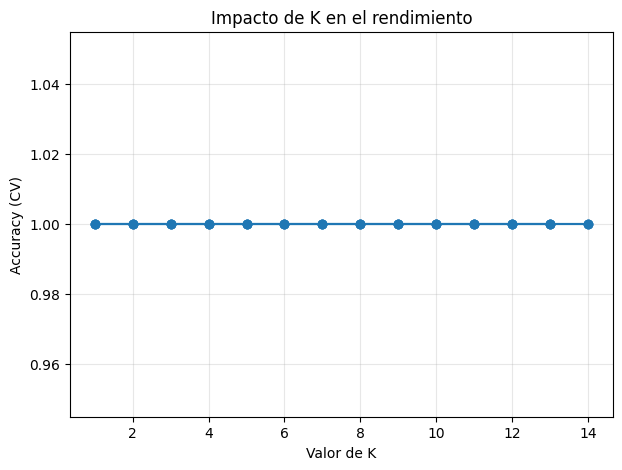

In [91]:
import numpy as np
import matplotlib.pyplot as plt

results = grid.cv_results_

mean_scores = results["mean_test_score"]
k_values = results["param_n_neighbors"].data

plt.figure(figsize=(7,5))
plt.plot(k_values, mean_scores, marker="o")
plt.xlabel("Valor de K")
plt.ylabel("Accuracy (CV)")
plt.title("Impacto de K en el rendimiento")
plt.grid(alpha=0.3)
plt.show()

**8) Graficar fronteras de decisión (2D)**

In [92]:
Z = best_model.predict(np.c_[xx.ravel(), yy.ravel()])
print(type(Z))
print(getattr(Z, "dtype", "sin_dtype"))
print(np.unique(Z)[:10])


<class 'numpy.ndarray'>
object
['Baloncesto' 'Futbol']


TypeError: ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

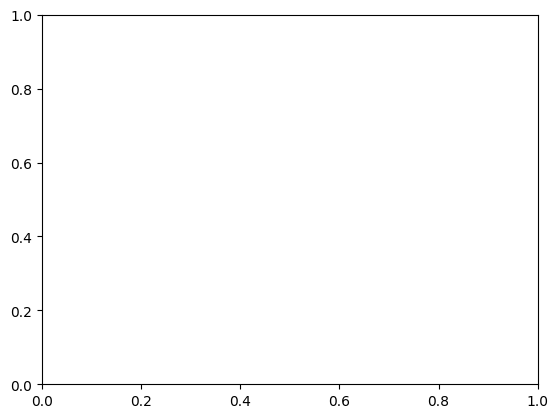

In [96]:
import numpy as np

# Crear malla
x_min, x_max = X_scaled[:,0].min() - 1, X_scaled[:,0].max() + 1
y_min, y_max = X_scaled[:,1].min() - 1, X_scaled[:,1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

Z = best_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# factorizar etiquetas (texto -> 0,1,2,...) igual que haces con y
#Z_num, _ = pd.factorize(Z)
#Z = Z_num.astype(float).reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)

plt.figure(figsize=(7,6))
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=pd.factorize(y)[0],
    edgecolor="k"
)

plt.xlabel("Altura (escalada)")
plt.ylabel("Peso (escalado)")
plt.title("Frontera de decisión KNN")
plt.show()

**9) Guardar modelo con joblib**

In [ ]:
import joblib

joblib.dump(best_model, "modelo_knn_deportes.pkl")
joblib.dump(scaler, "scaler_deportes.pkl")

print("Modelo guardado correctamente.")

## Ejercicio 2: CLASIFICADOR DEPORTIVO K-NN

1. Importar librerías necesarias

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
import pandas as pd
import numpy as np

# Para reproducibilidad
np.random.seed(42)

# Generar datos para futbol
n_fut = 30
altura_fut = np.random.normal(loc=170, scale=5, size=n_fut).round(1)
peso_fut   = np.random.normal(loc=68,  scale=4, size=n_fut).round(1)

# Generar datos para baloncesto
n_bal = 30
altura_bal = np.random.normal(loc=190, scale=5, size=n_bal).round(1)
peso_bal   = np.random.normal(loc=85,  scale=5, size=n_bal).round(1)

# Construir DataFrame
df_i = pd.DataFrame({
    "altura": np.concatenate([altura_fut, altura_bal]),
    "peso":   np.concatenate([peso_fut, peso_bal]),
    "deporte": ["Futbol"]*n_fut + ["Baloncesto"]*n_bal
})

print("Dimensiones:", df_i.shape)
print(df_i.head())

Dimensiones: (60, 3)
   altura  peso deporte
0   172.5  65.6  Futbol
1   169.3  75.4  Futbol
2   173.2  67.9  Futbol
3   177.6  63.8  Futbol
4   168.8  71.3  Futbol


In [ ]:
df_i.to_csv("deportes.csv", index=False)
print("Archivo 'deportes.csv' creado correctamente.")

Archivo 'deportes.csv' creado correctamente.


In [ ]:
df = pd.read_csv("deportes.csv")

print(df.head())
print(df["deporte"].value_counts())

   altura  peso deporte
0   172.5  65.6  Futbol
1   169.3  75.4  Futbol
2   173.2  67.9  Futbol
3   177.6  63.8  Futbol
4   168.8  71.3  Futbol
deporte
Futbol        30
Baloncesto    30
Name: count, dtype: int64


In [ ]:
X = df[["altura", "peso"]]
y = df["deporte"]

2. Escale las variables usando StandardScaler.

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

3. Divide los datos en entrenamiento y test (70/30).

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

4. Entrene un modelo K-NN (K=3) y evalue con matriz de confusión y accuracy.

In [ ]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nMatriz de confusión:\n", confusion_matrix(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0

Matriz de confusión:
 [[9 0]
 [0 9]]

Classification report:
               precision    recall  f1-score   support

  Baloncesto       1.00      1.00      1.00         9
      Futbol       1.00      1.00      1.00         9

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
weighted avg       1.00      1.00      1.00        18



5. Visualice las fronteras de decisión en un gráfico 2D.

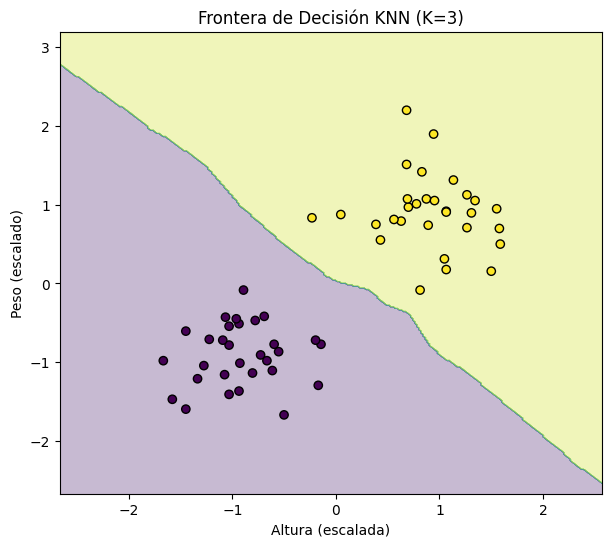

In [ ]:
# Crear malla
x_min, x_max = X_scaled[:,0].min()-1, X_scaled[:,0].max()+1
y_min, y_max = X_scaled[:,1].min()-1, X_scaled[:,1].max()+1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

Z_raw = knn.predict(np.c_[xx.ravel(), yy.ravel()])

# Get the numerical mapping from the target variable y to ensure consistency
factorized_y, unique_labels = pd.factorize(y)
label_to_int = {label: i for i, label in enumerate(unique_labels)}

# Convert the predicted string labels to their integer representation
Z = np.array([label_to_int[label] for label in Z_raw])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(7,6))
plt.contourf(xx, yy, Z, alpha=0.3)

plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=factorized_y, # Use the same factorized values for consistency
    edgecolor="k"
)

plt.xlabel("Altura (escalada)")
plt.ylabel("Peso (escalado)")
plt.title("Frontera de Decisión KNN (K=3)")
plt.show()

6. Probar valores de K entre 1 y 10, evaluando con validación cruzada.

In [ ]:
k_values = range(1, 11)
scores = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    cv_score = cross_val_score(model, X_scaled, y, cv=5).mean()
    scores.append(cv_score)

best_k = k_values[np.argmax(scores)]

print("Mejor K:", best_k)
print("Mejor score CV:", max(scores))

Mejor K: 1
Mejor score CV: 1.0


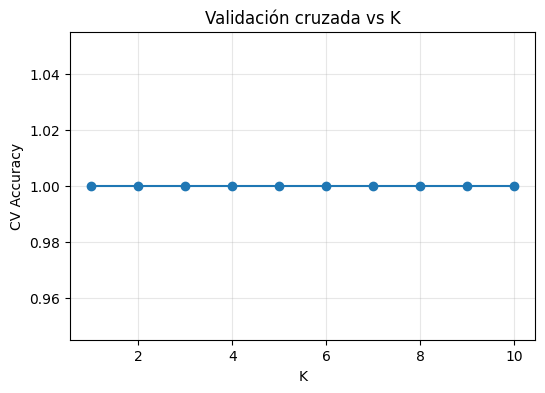

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(k_values, scores, marker="o")
plt.xlabel("K")
plt.ylabel("CV Accuracy")
plt.title("Validación cruzada vs K")
plt.grid(alpha=0.3)
plt.show()

7. Exporte el modelo entrenado como .pkl.

In [ ]:
modelo_final = KNeighborsClassifier(n_neighbors=best_k)
modelo_final.fit(X_scaled, y)

joblib.dump(modelo_final, "modelo_knn_deportes.pkl")
joblib.dump(scaler, "scaler_deportes.pkl")

print("Modelo guardado correctamente.")

Modelo guardado correctamente.
